# Ensemble GMM sweep (efficient)

Optimized version of `Ensemble_100_parallel.ipynb`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import tempfile, os
import gsw
from sklearn.mixture import GaussianMixture
from joblib import Parallel, delayed, cpu_count
from tqdm import tqdm
from funcs import cross_sec_lon, cross_sec_lon_prob, cross_sec_lon_prob2, calc_pv, method34

In [3]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2_with_PV.csv')

In [4]:
# Preprocess data to contain the relevant features
cols = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]',
        'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]',
        'Longitude_[deg_E]', 'Profile_Number', 'PV', 'dPVdz']
df_ST = df[cols + ['Datetime_[UTC]']].copy()

# Parse the datetime column once, then pull out year/month
dt = pd.to_datetime(df_ST['Datetime_[UTC]'])
df_ST['year'] = dt.dt.year
df_ST['month'] = dt.dt.month

df_ST = df_ST[df_ST['year'] >= 1980]  # remove the few points before 1980 (only 7 points)
df_ST = df_ST[cols + ['year', 'month']]

In [5]:
# Define random master seed for reproducibility
master_seed = 22
random.seed(master_seed)

# Ensemble size
ensemble_size = 100

# Define a list of random seeds
seeds = random.sample(range(1, 10000), ensemble_size)

In [6]:
# Define features to use for clustering
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'dPVdz']

In [7]:
df_sampled = method34(df=df_ST, seed=master_seed)

In [8]:
# --- Efficient ensemble GMM sweep ---
# Strategy: memory-map X once so workers share it without copying, then
# parallelize over SEEDS. Each worker draws its 500k subsample a single time
# and reuses it across all component counts (the original redrew it per fit).

n_components_range = range(1, 8)
subsample_size = 500_000

# Write X to a memory-mapped temp file — workers read it directly, no copying
X = df_sampled[features].to_numpy()
tmp = tempfile.mktemp(suffix='.npy')
np.save(tmp, X)
X_memmap = np.load(tmp, mmap_mode='r')
del X  # free the in-memory copy


def fit_gmm_seed(seed, n_components_range, subsample_size, X):
    """Fit GMMs for all component counts on one seed's subsample.

    The subsample is drawn (and read out of the memmap) once per seed and
    reused for every component count.
    """
    rng = np.random.default_rng(seed)
    size = min(subsample_size, len(X))
    idx = np.sort(rng.choice(len(X), size=size, replace=False))  # sorted -> sequential memmap reads
    X_sub = np.asarray(X[idx])  # materialize the subsample once

    bics, aics = [], []
    for n in n_components_range:
        gmm = GaussianMixture(
            n_components=n,
            covariance_type='full',
            random_state=seed,
            max_iter=10_000,
            n_init=1,
        )
        gmm.fit(X_sub)
        bics.append(gmm.bic(X_sub))
        aics.append(gmm.aic(X_sub))
    return bics, aics


cores_used = cpu_count()
total_fits = len(seeds) * len(n_components_range)
print(f"Fitting {total_fits} GMMs ({len(seeds)} seeds \u00d7 {len(n_components_range)} components)")
print(f"CPU cores available: {cores_used}")
print(f"Full data shape: {X_memmap.shape} | Subsample per seed: {subsample_size:,} rows")
print()

try:
    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(fit_gmm_seed)(seed, n_components_range, subsample_size, X_memmap)
        for seed in tqdm(seeds, desc="Fitting GMMs", unit="seed")
    )
finally:
    os.remove(tmp)  # always clean up temp file

# Reconstruct the same dict structure as before: {seed_index: [score per n_components]}
all_scores = {i: bics for i, (bics, aics) in enumerate(results)}
all_aic_scores = {i: aics for i, (bics, aics) in enumerate(results)}

print(f"\nDone. {total_fits} fits completed.")

Fitting 700 GMMs (100 seeds × 7 components)
CPU cores available: 12
Full data shape: (5099531, 3) | Subsample per seed: 500,000 rows



Fitting GMMs: 100%|██████████| 100/100 [20:22<00:00, 12.22s/seed]



Done. 700 fits completed.


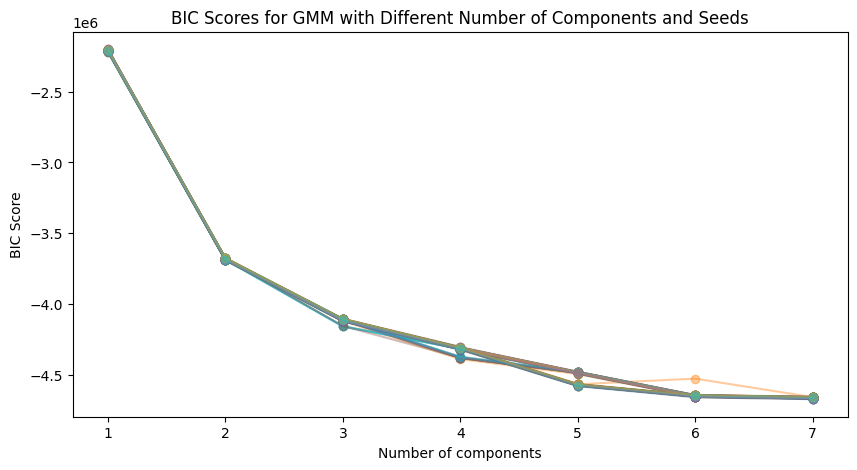

In [9]:
plt.figure(figsize=(10, 5))
for i in range(len(seeds)):
    plt.plot(n_components_range, all_scores[i], marker='o', alpha=0.4)
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components and Seeds')
plt.show()

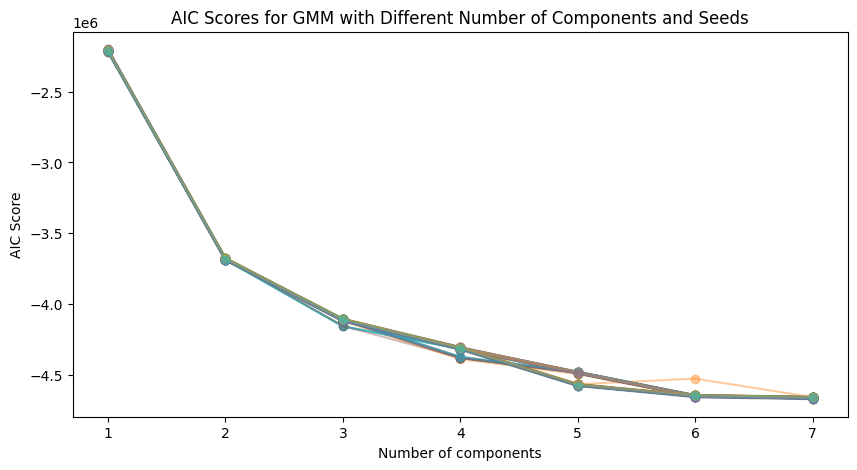

In [10]:
plt.figure(figsize=(10, 5))
for i in range(len(seeds)):
    plt.plot(n_components_range, all_aic_scores[i], marker='o', alpha=0.4)
plt.xlabel('Number of components')
plt.ylabel('AIC Score')
plt.title('AIC Scores for GMM with Different Number of Components and Seeds')
plt.show()

## Fit the ensemble at the chosen K and match clusters across members

Having picked the optimal number of clusters from the BIC/AIC sweep, refit **every** ensemble member at that K on the full dataset, then match each member's clusters to a common set of reference classes (Poropat et al. 2024) so cluster variability between members can be quantified.

The only change from the original is that the per-member fit is **parallelised over seeds** instead of running in a serial loop.

In [11]:
# Choice of optimal number of clusters based on BIC
n_clusters = 6

In [12]:
# --- Fit every ensemble member at the chosen K, on the FULL data, in parallel ---
# The original did this in a serial for-loop (one member at a time). Here we
# parallelise over seeds with the same shared-memmap trick as the sweep, so all
# cores fit members concurrently. Each worker also predicts labels on the full
# data and returns them as int8 (K <= 127), keeping the transfer back small.

X = df_sampled[features].to_numpy()
tmp = tempfile.mktemp(suffix='.npy')
np.save(tmp, X)
X_memmap = np.load(tmp, mmap_mode='r')
del X  # free the in-memory copy


def fit_member(seed, n_clusters, X):
    gmm = GaussianMixture(
        n_components=n_clusters,   # number of clusters
        covariance_type='full',    # full cov matrix has more flexibility
        random_state=seed,
    )
    gmm.fit(X)
    return gmm, gmm.predict(X).astype(np.int8)


print(f"Fitting {len(seeds)} ensemble members on full data {X_memmap.shape} at K={n_clusters}")
print(f"CPU cores available: {cpu_count()}")
print()

try:
    fitted = Parallel(n_jobs=-1, backend="loky")(
        delayed(fit_member)(seed, n_clusters, X_memmap)
        for seed in tqdm(seeds, desc="Fitting members", unit="member")
    )
finally:
    os.remove(tmp)  # always clean up temp file

# Same outputs as the original serial loop: a list of fitted GMMs and per-member labels.
gmms   = [g for g, _ in fitted]
labels = [lab for _, lab in fitted]

print(f"Done. {len(gmms)} members fitted at K={n_clusters}.")

Fitting 100 ensemble members on full data (5099531, 3) at K=6
CPU cores available: 12



Fitting members:  37%|███▋      | 37/100 [31:37<1:00:10, 57.31s/member]

KeyboardInterrupt: 

In [24]:
# Preprocess for comparrison of cluster labels across different seeds
# Clusters with similar mean T, S and D (depth) should be matched across different seeds
cluster_means = []
for i in range(ensemble_size):
    means = gmms[i].means_
    cluster_means.append(means)

# Match clusters across different seeds based on closest mean T, S and D (depth)
matched_labels = []
for i in range(ensemble_size):
    means = cluster_means[i]
    matched = np.zeros(n_clusters, dtype=int)
    for j in range(n_clusters):
        mean_T = means[j, 0]
        mean_S = means[j, 1]
        min_dist = np.inf
        match = -1
        for k in range(n_clusters):
            dist = np.sqrt((mean_T - cluster_means[0][k, 0])**2 + (mean_S - cluster_means[0][k, 1])**2)
            if dist < min_dist:
                min_dist = dist
                match = k
        matched[j] = match
    matched_labels.append(matched)

In [31]:
# Add matched cluster labels to the dataframe
for i in range(ensemble_size):
    df_sampled['gmm_label_'+str(i)] = matched_labels[i][labels[i]]

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_75158/2698519776.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sampled['gmm_label_'+str(i)] = matched_labels[i][labels[i]]


In [33]:
def cluster_overlap(df):
    """
    Compute overlap between aligned clusters across an ensemble of GMMs. 
    Create a mean cluster to use as reference.
    
    Parameters:
    - df: dataframe with columns for each GMM in the ensemble, 
        where each column contains the cluster labels for that GMM.

    Returns:
    - dict with overlap statistics for each aligned cluster.
    """

    # compute mode cluster labels across ensemble to use as reference
    mean_clusters = df[[f'gmm_label_{i}' for i in range(ensemble_size)]].mean(axis=1).round().astype(int)
    df['mean_cluster'] = mean_clusters # add mean cluster labels to dataframe
    
    n_clusters = len(set(df['gmm_label_0']))  # All have same number of clusters
    overlap_results = {}

    for k in range(n_clusters):

        cluster_k_mask = mean_clusters == k

        overlaps = []

        for i in range(1, ensemble_size):
            cluster_i_mask = df[f'gmm_label_{i}'] == k
            overlap_fraction = np.sum(cluster_k_mask & cluster_i_mask) / np.sum(cluster_k_mask)
            overlaps.append(overlap_fraction)

        overlap_results[k] = {
            "mean_overlap_fraction": np.mean(overlaps),
            "std_overlap_fraction": np.std(overlaps),
            "overlap_fractions": overlaps
        }

    return overlap_results, df

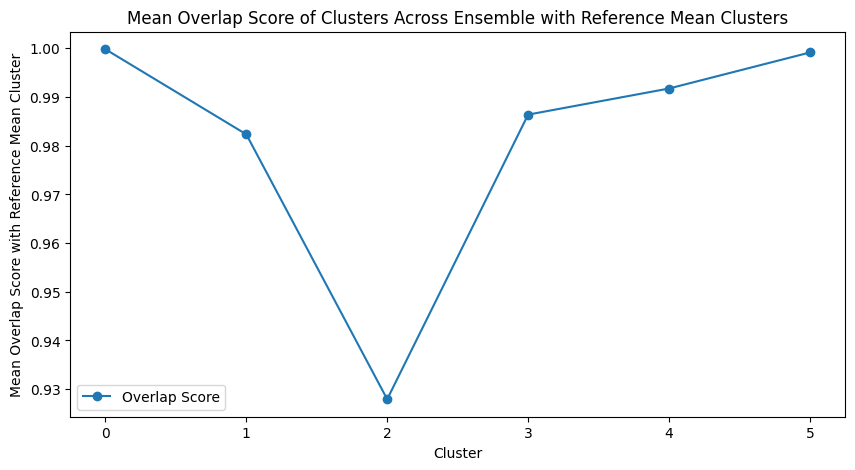

In [39]:
overlap, df_sampled = cluster_overlap(df_sampled)
plt.figure(figsize=(10,5))
plt.plot(range(n_clusters), [overlap[k]['mean_overlap_fraction'] for k in range(n_clusters)], label='Overlap Score', marker='o')
plt.xlabel('Cluster')
plt.ylabel('Mean Overlap Score with Reference Mean Cluster')
plt.title('Mean Overlap Score of Clusters Across Ensemble with Reference Mean Clusters')
plt.legend()
plt.show()

In [36]:
df_copy = df_sampled.copy()
df_copy['gmm_label_6'] = df_copy['mean_cluster']

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:626: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


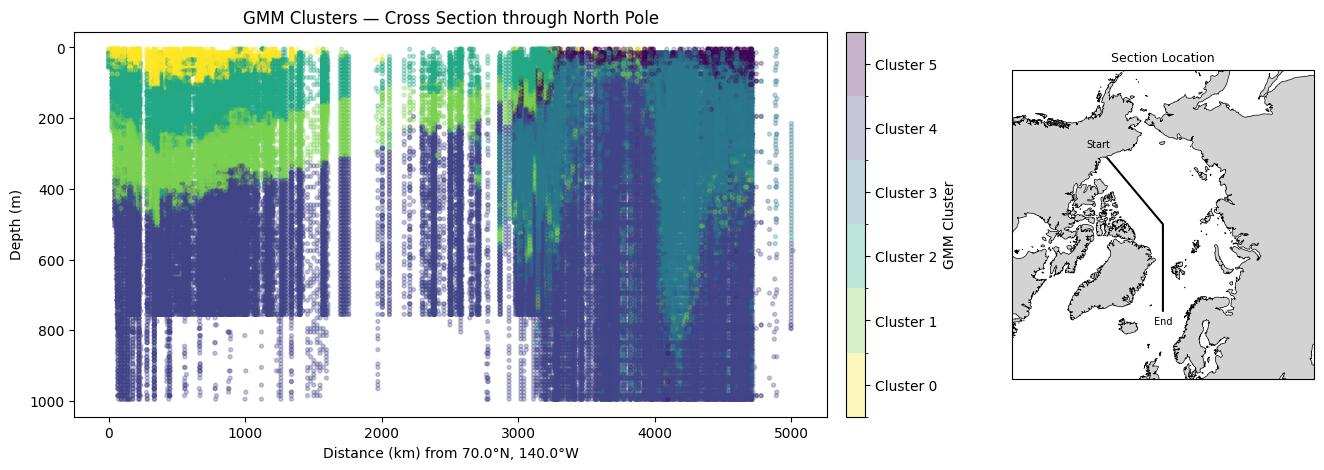

In [37]:
cross_sec_lon(df_copy, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140.0)

In [1]:
def _gmm_proba(gmm, matched, features, n_clusters):
    """Return shape (n_samples, n_clusters) for one GMM."""
    proba = gmm.predict_proba(features)
    return proba[:, [matched[j] for j in range(n_clusters)]]

proba_sum = np.zeros((len(df_copy), n_clusters))
batch_size = 4  # tune this

batches = [range(ensemble_size)[i:i+batch_size] 
           for i in range(0, ensemble_size, batch_size)]

for batch in tqdm(batches, desc="GMM batches", unit="batch"):
    batch_results = Parallel(n_jobs=len(batch), backend="loky")(
        delayed(_gmm_proba)(gmms[i], matched_labels[i], features, n_clusters)
        for i in batch
    )
    proba_sum += np.sum(batch_results, axis=0)

proba_mean = proba_sum / ensemble_size

for j in tqdm(range(n_clusters), desc="Writing clusters", unit="cluster"):
    df_copy[f'prob_mean_cluster_{j}'] = proba_mean[:, j]

NameError: name 'np' is not defined